In [1]:
from python_boilerplate.make_df import optimal_play_table, category_score
from python_boilerplate.simulations import simulate_n_times, simulate_forced_yatzy
from python_boilerplate.plotting import plot_histogram, category_distribution_plot
from python_boilerplate.expected_score import expected_value_for_game, find_category_distribution, extra_points_prob
from python_boilerplate.solver import build_value_layers
from python_boilerplate.utils import change_dice_representation
from statistics import mean
import python_boilerplate.scoring as s


In [2]:
prob_dist = find_category_distribution(s.one_pair)
print(prob_dist)

{2: 0.011695442203367847, 4: 0.012171741547979932, 6: 0.012648040892592008, 8: 0.053942919659316205, 10: 0.30584802087135887, 12: 0.5825673127843674, 0: 0.021126522041016768}


In [ ]:
category_distribution_plot(
    find_category_distribution(s.full_house),
    "Optimal Score Distribution for Full House",
    True
)

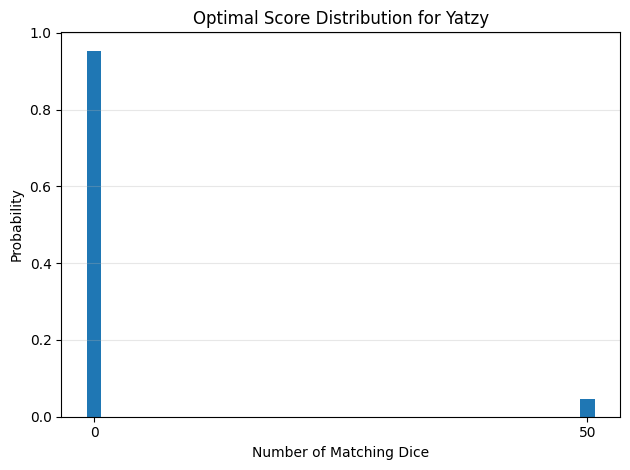

In [2]:
category_distribution_plot(
    find_category_distribution(s.yatzy),
    "Optimal Score Distribution for Yatzy",
    True
)

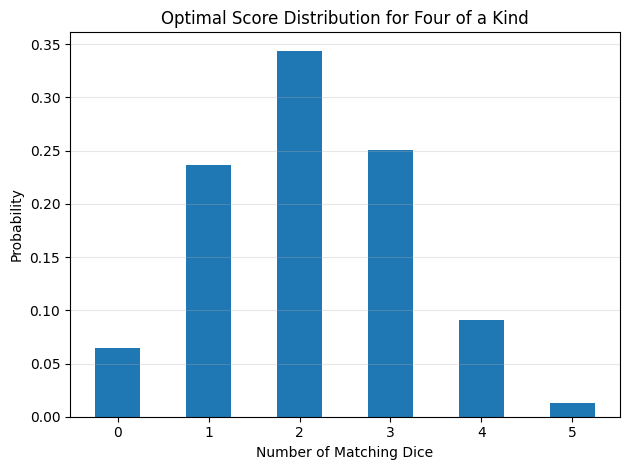

In [2]:
category_distribution_plot(
    find_category_distribution(s.same_face_value, 1),
    "Optimal Score Distribution for Four of a Kind",
    True
)

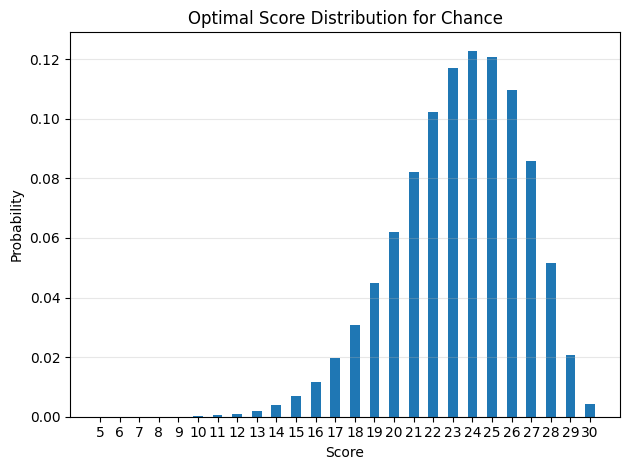

In [3]:
category_distribution_plot(
    find_category_distribution(s.chance),
    "Optimal Score Distribution for Chance"
)

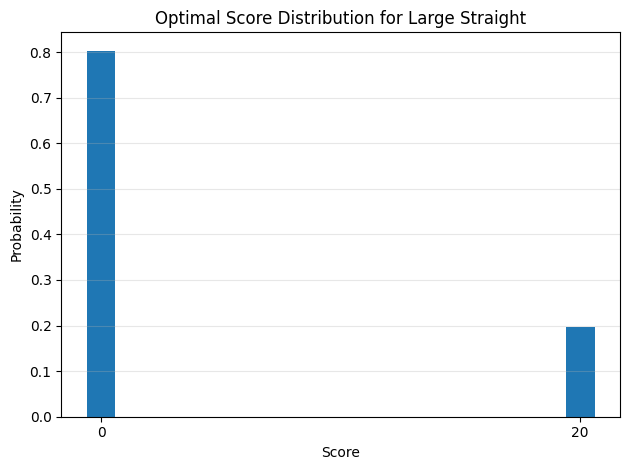

In [6]:
category_distribution_plot(
    find_category_distribution(s.large_straight),
    "Optimal Score Distribution for Large Straight"
)

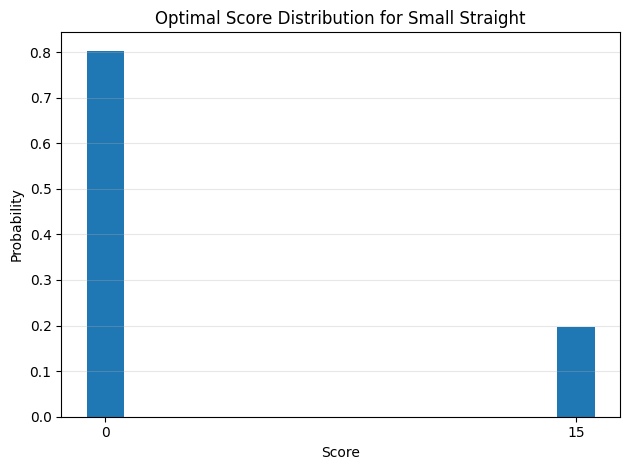

In [5]:
category_distribution_plot(
    find_category_distribution(s.small_straight),
    "Optimal Score Distribution for Small Straight"
)

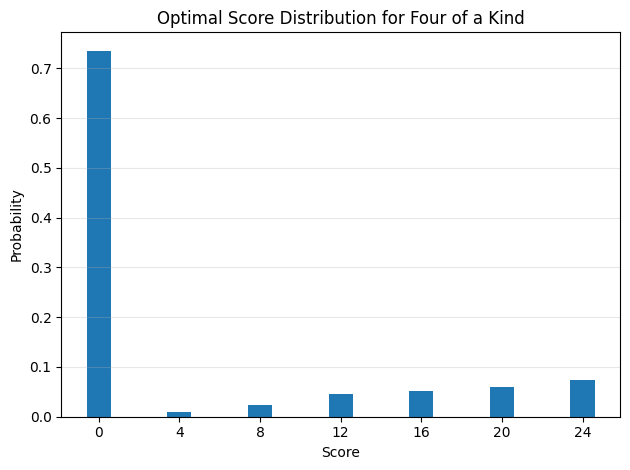

In [4]:
category_distribution_plot(
    find_category_distribution(s.four_of_a_kind),
    "Optimal Score Distribution for Four of a Kind"
)

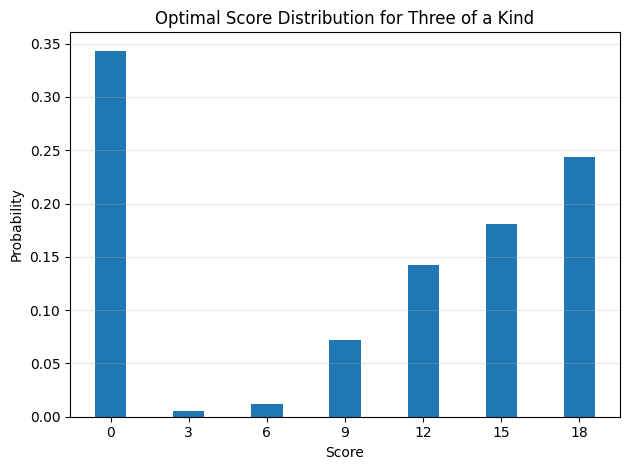

In [2]:
category_distribution_plot(
    find_category_distribution(s.three_of_a_kind),
    "Optimal Score Distribution for Three of a Kind"
)

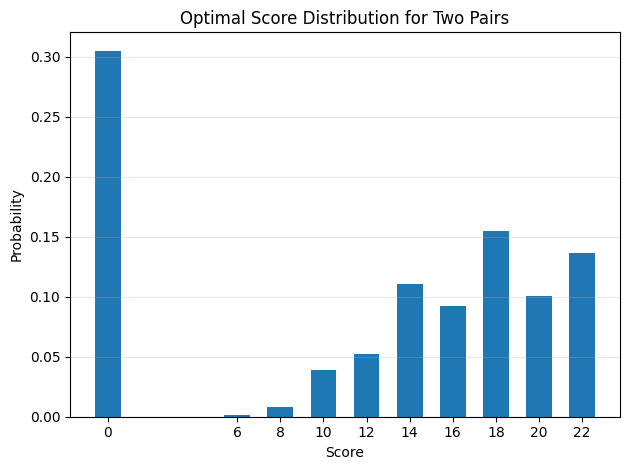

In [3]:
category_distribution_plot(
    find_category_distribution(s.two_pairs), 
    "Optimal Score Distribution for Two Pairs")

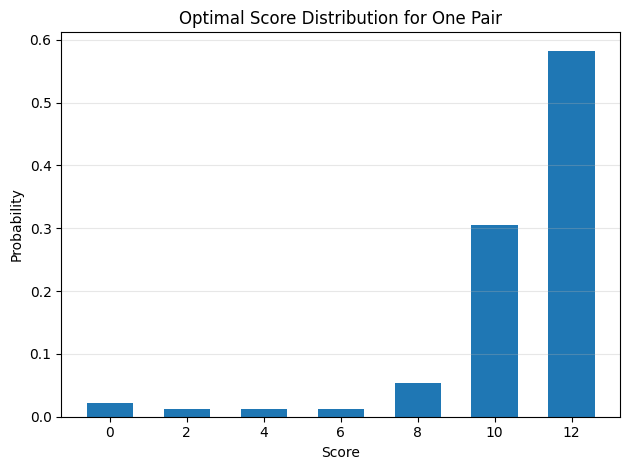

In [3]:
category_distribution_plot(prob_dist, "Optimal Score Distribution for One Pair")

In [5]:
df = optimal_play_table()


In [ ]:
df

,Hand,Hold,Expected_value,Throws_left,Category_name,Category_number
0,"(5, 0, 0, 0, 0, 0)",None,5.000000,0,ones,1
1,"(4, 1, 0, 0, 0, 0)",None,4.000000,0,ones,1
2,"(4, 0, 1, 0, 0, 0)",None,4.000000,0,ones,1
3,"(4, 0, 0, 1, 0, 0)",None,4.000000,0,ones,1
4,"(4, 0, 0, 0, 1, 0)",None,4.000000,0,ones,1
...,...,...,...,...,...,...
751,"(0, 0, 0, 0, 4, 1)","(0, 0, 0, 0, 4, 0)",15.277778,2,yatzy,15
752,"(0, 0, 0, 0, 3, 2)","(0, 0, 0, 0, 3, 0)",4.668210,2,yatzy,15
753,"(0, 0, 0, 0, 2, 3)","(0, 0, 0, 0, 0, 3)",4.668210,2,yatzy,15
754,"(0, 0, 0, 0, 1, 4)","(0, 0, 0, 0, 0, 4)",15.277778,2,yatzy,15


In [4]:
df_new = change_dice_representation(df)

In [6]:
latex_table = df_new.to_latex(
    index = False,
    escape = False,
    longtable=True,
)

with open("decision_table.tex", "w") as f:
    f.write(latex_table)

In [9]:
simulate_forced_yatzy(df, log = True)


--------------- ones-----------------

Current score :  0
Current hand :  (2, 0, 1, 2, 0, 0)
Optimal hold :  (2, 0, 0, 0, 0, 0)
Current hand :  (3, 0, 0, 1, 1, 0)
Optimal hold :  (3, 0, 0, 0, 0, 0)
last hand :  (3, 1, 1, 0, 0, 0)

Score of round :  3.0

Current score :  3.0

--------------- twos-----------------

Current score :  3.0
Current hand :  (0, 0, 0, 3, 1, 1)
Optimal hold :  (0, 0, 0, 0, 0, 0)
Current hand :  (0, 1, 0, 0, 1, 3)
Optimal hold :  (0, 1, 0, 0, 0, 0)
last hand :  (0, 1, 0, 1, 2, 1)

Score of round :  2.0

Current score :  5.0

--------------- threes-----------------

Current score :  5.0
Current hand :  (1, 1, 0, 0, 3, 0)
Optimal hold :  (0, 0, 0, 0, 0, 0)
Current hand :  (0, 3, 0, 1, 0, 1)
Optimal hold :  (0, 0, 0, 0, 0, 0)
last hand :  (0, 2, 0, 3, 0, 0)

Score of round :  0.0

Current score :  5.0

--------------- fours-----------------

Current score :  5.0
Current hand :  (1, 2, 2, 0, 0, 0)
Optimal hold :  (0, 0, 0, 0, 0, 0)
Current hand :  (0, 1, 0, 2, 0, 2)

np.float64(162.0)

In [7]:
print(extra_points_prob())

0.5967411808494929


In [6]:
category_score_results = category_score()
category_score_results

,Category_name,Optimal_score
0,ones,2.106481
1,twos,4.212963
2,threes,6.319444
3,fours,8.425926
4,fives,10.532407
5,sixes,12.638889
6,one pair,10.628797
7,two pairs,11.907547
8,three of a kind,9.545416
9,four of a kind,4.572357


In [6]:

# score_test = simulate_forced_yatzy(df)
score_list = simulate_n_times(10000, df)

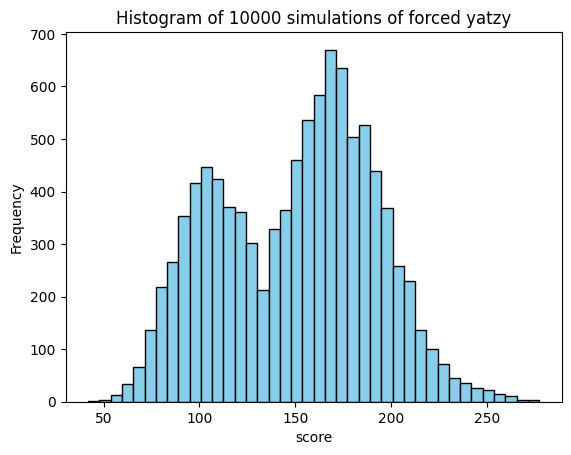

In [7]:

plot_histogram(score_list[0])

In [8]:
print(f"From 10000 simulation {score_list[1]} was the frequency of times bonus points was achieved.")

From 10000 simulation 0.5935 was the frequency of times bonus points was achieved.


In [9]:
print("Mean of simulated games playing optimally : ", mean(score_list))
print("Expected score playing optimally : ", expected_value_for_game(category_score_results))

TypeError: can't convert type 'list' to numerator/denominator